# Projet de Scoring de Crédit : Prédiction du Défaut de Paiement
**Présenté par : [Sahli Wissem]**

## 1. Introduction
L'objectif de ce projet est de prédire le risque de défaut de paiement (`Status`) à partir d'un jeu de données bancaires complexe contenant 34 variables. 

### Problématique :
Comment identifier les facteurs discriminants (financiers et démographiques) qui permettent d'anticiper l'incapacité d'un emprunteur à rembourser son prêt ?

## 2. Chargement des données
Nous utilisons la bibliothèque `kagglehub` pour récupérer la version la plus récente du dataset "Loan Default Dataset".

Installation des bibliothèques nécessaires pour l'analyse de données, la gestion des datasets et le machine learning 

In [235]:
import sys
!{sys.executable} -m pip install kagglehub pandas matplotlib seaborn scikit-learn imbalanced-learn scipy

In [236]:
import kagglehub
from pathlib import Path
import shutil
import os 


# création du dossier local ( qui contiendra la base )

data_folder = Path('data')
data_folder.mkdir(exist_ok=True)

# téléchargement de la base avec Kaggle API

try : 
    path = Path(kagglehub.dataset_download("yasserh/loan-default-dataset"))
    print("Téléchargement de la dernière version réussi.")

    files = [ f for f in os.listdir(path) if f.endswith(".csv")]
    src_file = path / files[0]
    data = data_folder / "data.csv"

    shutil.copy(src_file , data )
    print(f"Fichier copié avec succès dans : {data}")

except Exception as e :
    print(f"Erreur : {e}")



Téléchargement de la dernière version réussi.
Fichier copié avec succès dans : data\data.csv


In [237]:
import pandas as pd 

df = pd.read_csv(data)
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## 3. Exploration et Nettoyage des Données

In [238]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [239]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

## Les valeurs dupliquées

In [241]:
df = df.drop_duplicates()

## Les valeurs manquantes

In [242]:
print('Pourcentage des valeurs manquantes par colonnes : \n')

missing = (df.isnull().mean()*100).round(2).sort_values(ascending=False) 
print (missing[ missing > 0])

Pourcentage des valeurs manquantes par colonnes : 

Upfront_charges              26.66
Interest_rate_spread         24.64
rate_of_interest             24.51
dtir1                        16.22
property_value               10.16
LTV                          10.16
income                        6.15
loan_limit                    2.25
approv_in_adv                 0.61
age                           0.13
submission_of_application     0.13
loan_purpose                  0.09
Neg_ammortization             0.08
term                          0.03
dtype: float64


In [243]:
high_missing = ['Upfront_charges', 'Interest_rate_spread', 'rate_of_interest', 'dtir1', 'property_value', 'LTV']

In [244]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df_numeric = df.select_dtypes(include=[np.number])
df_categorical = df.select_dtypes(exclude=[np.number])

# Pour les variables numériques !

numeric_imputer = IterativeImputer(max_iter=10, random_state=42)
numeric_imputed = numeric_imputer.fit_transform(df_numeric)

# Pour les variables catégoriques !
categorical_imputer = SimpleImputer(strategy="most_frequent")
categorical_imputed = categorical_imputer.fit_transform(df_categorical)

# construction de la dataFrame finale
df = pd.concat([
    pd.DataFrame(numeric_imputed, columns=df_numeric.columns),
    pd.DataFrame(categorical_imputed, columns=df_categorical.columns)
], axis=1)
print("Imputation réussie ! \n")

"""
print(f"Médianes calculées pour les variables numériques : \n")
for i in range(len(numeric_imputer.statistics_)):
    print(f"{numeric_imputer.feature_names_in_[i]} : {round(numeric_imputer.statistics_[i],2)}")
"""
print()

Imputation réussie ! 




## Les valeurs presques constantes

In [245]:
for i in df.columns:

    num_uniques = df[i].nunique()

    if num_uniques < 3:
        print(f"--- Variable : {i} ({num_uniques} valeurs uniques) ---")
        print(df[i].value_counts(), '\n')

--- Variable : year (1 valeurs uniques) ---
year
2019.0    148670
Name: count, dtype: int64 

--- Variable : Status (2 valeurs uniques) ---
Status
0.0    112031
1.0     36639
Name: count, dtype: int64 

--- Variable : loan_limit (2 valeurs uniques) ---
loan_limit
cf     138692
ncf      9978
Name: count, dtype: int64 

--- Variable : approv_in_adv (2 valeurs uniques) ---
approv_in_adv
nopre    125529
pre       23141
Name: count, dtype: int64 

--- Variable : Credit_Worthiness (2 valeurs uniques) ---
Credit_Worthiness
l1    142344
l2      6326
Name: count, dtype: int64 

--- Variable : open_credit (2 valeurs uniques) ---
open_credit
nopc    148114
opc        556
Name: count, dtype: int64 

--- Variable : business_or_commercial (2 valeurs uniques) ---
business_or_commercial
nob/c    127908
b/c       20762
Name: count, dtype: int64 

--- Variable : Neg_ammortization (2 valeurs uniques) ---
Neg_ammortization
not_neg    133541
neg_amm     15129
Name: count, dtype: int64 

--- Variable : inte

In [246]:
print(df["Secured_by"].value_counts(),'\n')
print(df["Security_Type"].value_counts(),'\n')
print(df["construction_type"].value_counts(),'\n')

df = df.drop(columns=['Security_Type','Secured_by','construction_type'])

# Supprimer les colonnes inutiles ( id - year )
df = df.drop(columns=['ID','year'])

print("==> Supprimation finie des colonnes : ID - Year - Security - construction_type")

Secured_by
home    148637
land        33
Name: count, dtype: int64 

Security_Type
direct      148637
Indriect        33
Name: count, dtype: int64 

construction_type
sb    148637
mh        33
Name: count, dtype: int64 

==> Supprimation finie des colonnes : ID - Year - Security - construction_type


In [250]:
df.to_csv('data/cleaned.csv',index=False)
print("Enregistrer dans le dossier data : cleaned.csv")

Enregistrer dans le dossier data : cleaned.csv


In [248]:
print(df[df['LTV'] > 500]['LTV'].value_counts())
df = df[df['LTV'] <= 500]


LTV
7831.25    1
2956.25    1
5206.25    1
6706.25    1
4706.25    1
2331.25    1
Name: count, dtype: int64


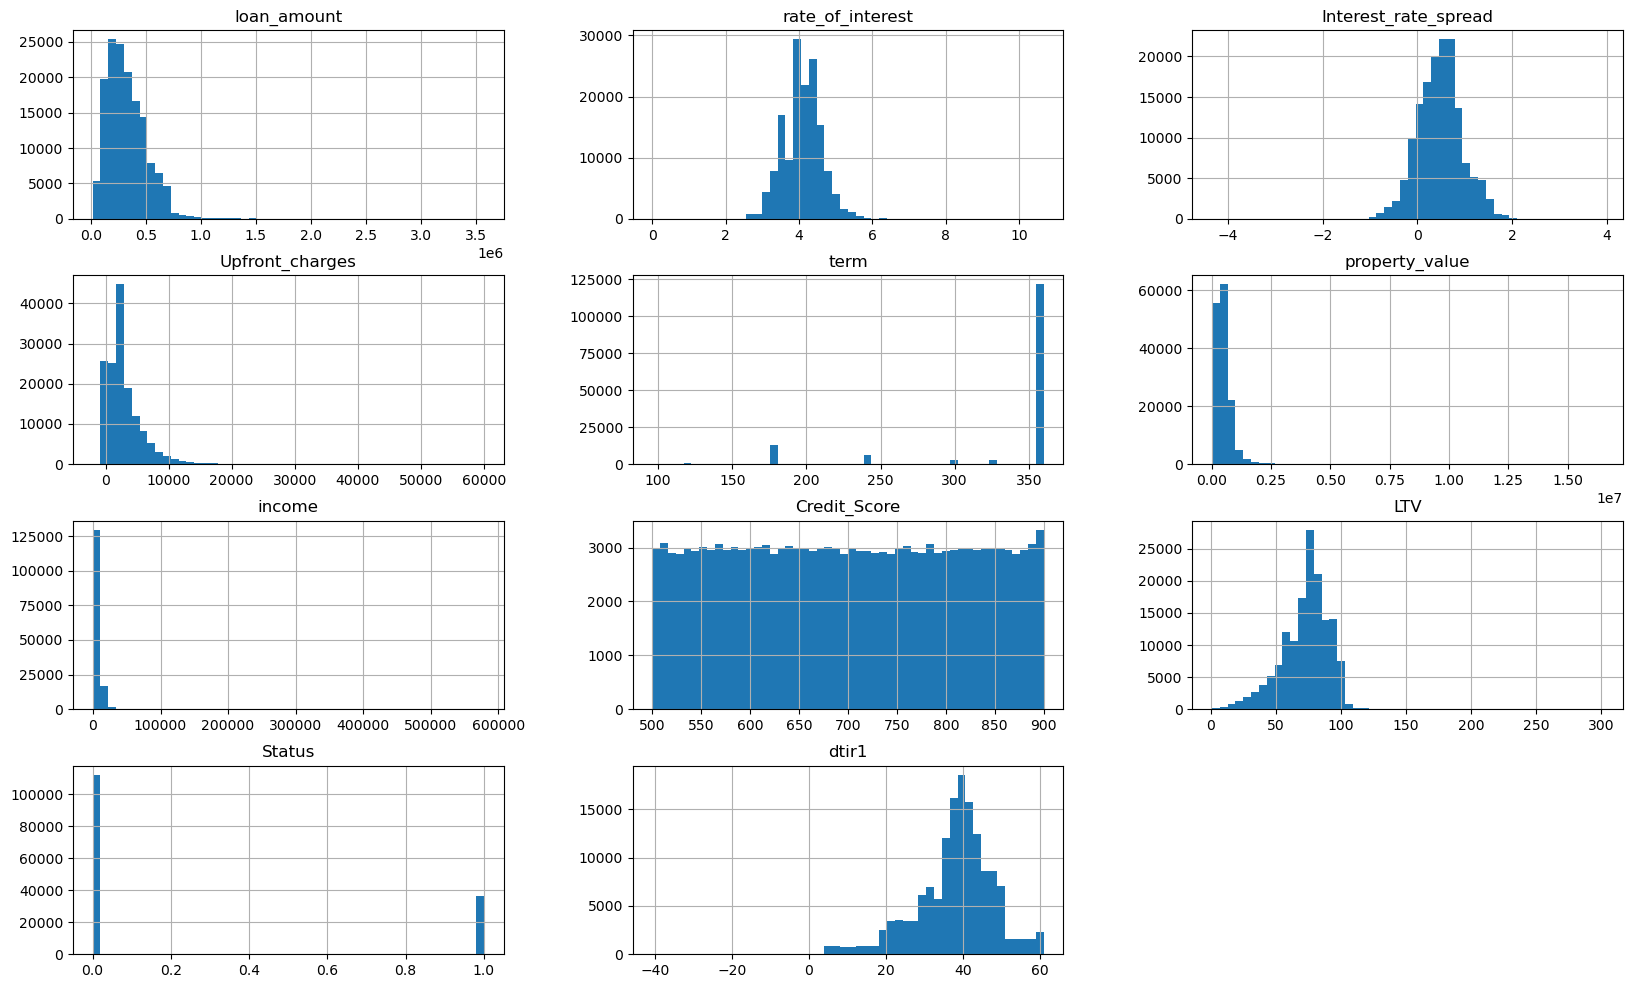

In [249]:
import matplotlib.pyplot as plt 
import seaborn as sbn 

df.hist(bins=50, figsize=(20,12))
plt.show()
